In [1]:
import tensorflow as tf
physical_devices = tf.config.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)
tf.config.set_visible_devices(physical_devices[0], 'GPU')

In [2]:
import numpy
numpy.__version__

'1.26.2'

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape,Input, ZeroPadding2D, Conv2D, BatchNormalization, Activation, Dropout,MaxPooling2D, Flatten, Dense, LSTM
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
import time
from os import listdir

%matplotlib inline

In [4]:
def crop_brain_contour(image, plot=False):
 
    # Convert the image to grayscale, and blur it slightly
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)
    

    # Find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    
    # crop new image out of the original image using the four extreme points (left, right, top, bottom)
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]            

    if plot:
        plt.figure()

        plt.subplot(1, 2, 1)
        plt.imshow(image)
        
        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        
        plt.title('Original Image')
            
        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')
        
        plt.show()
    
    return new_image

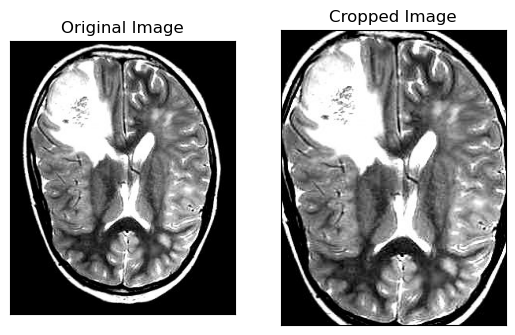

In [5]:
ex_img = cv2.imread('Dataset\\yes\\y0.jpg')
ex_new_img = crop_brain_contour(ex_img, True)

In [6]:
def load_data(dir_list, image_size):

    # load all images in a directory
    X = []
    y = []
    image_width, image_height = image_size
    
    for directory in dir_list:
        for filename in listdir(directory):
            # load the image
            image = cv2.imread(directory + '\\' + filename)
            # crop the brain and ignore the unnecessary rest part of the image
            image = crop_brain_contour(image, plot=False)
            # resize image
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            # normalize values
            image = image / 255.
            # convert image to numpy array and append it to X
            X.append(image)

            if directory[-3:] == 'yes':
                y.append([1])
            else:
                y.append([0])
                
    X = np.array(X)
    y = np.array(y)
    
    # Shuffle the data
    X, y = shuffle(X, y)
    
    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')
    
    return X, y

In [7]:
augmented_path = 'Dataset\\'

# augmented data (yes and no) contains both the original and the new generated examples
augmented_yes = augmented_path + 'yes' 
augmented_no = augmented_path + 'no'

IMG_WIDTH, IMG_HEIGHT = (240, 240)

X, y = load_data([augmented_yes, augmented_no], (IMG_WIDTH, IMG_HEIGHT))

Number of examples is: 3000
X shape is: (3000, 240, 240, 3)
y shape is: (3000, 1)


In [8]:
def plot_sample_images(X, y, n=50):

    
    for label in [0,1]:
        # grab the first n images with the corresponding y values equal to label
        images = X[np.argwhere(y == label)]
        n_images = images[:n]
        
        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))
        
        i = 1 # current plot        
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])
            
            # remove ticks
            plt.tick_params(axis='both', which='both', 
                            top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)
            
            i += 1
        
        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

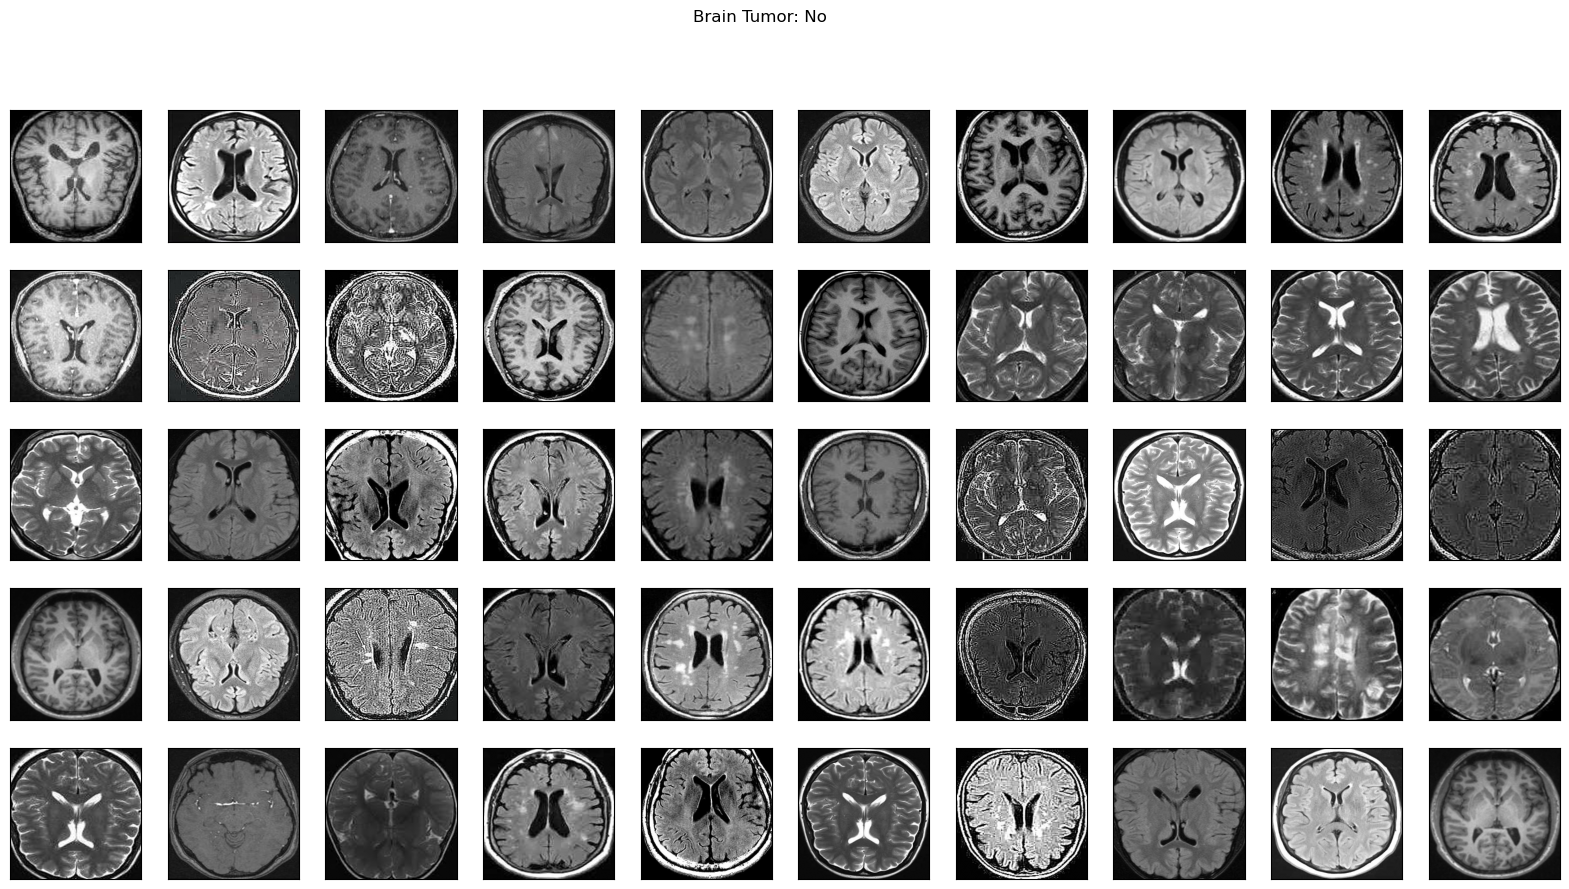

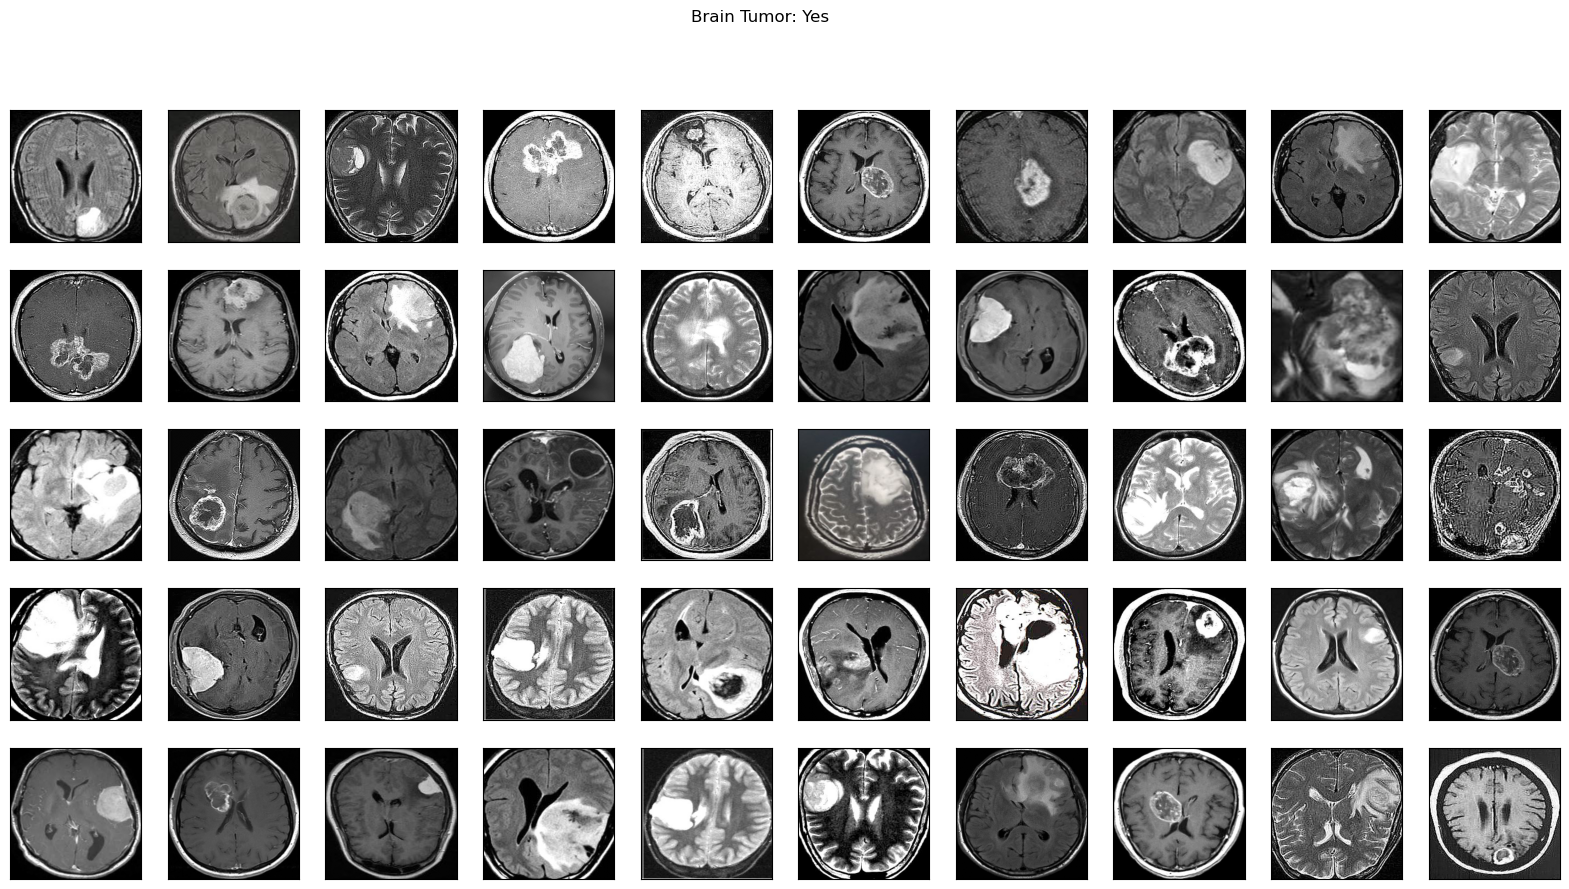

In [9]:
plot_sample_images(X, y)

In [10]:
def split_data(X, y, test_size=0.2):
       
    
    X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=test_size)
    X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [11]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, test_size=0.3)

In [12]:
# def build_model(input_shape):
#     model = Sequential()
    
#     # Convolutional layers
#     model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
#     model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
#     model.add(MaxPooling2D(pool_size=(2, 2)))
#     model.add(Dropout(0.25))
    
#     model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
#     model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
#     model.add(MaxPooling2D(pool_size=(2, 2)))
#     model.add(Dropout(0.25))
    
#     model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
#     model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
#     model.add(MaxPooling2D(pool_size=(2, 2)))
#     model.add(Dropout(0.25))
    
#     model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
#     model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
#     model.add(MaxPooling2D(pool_size=(2, 2)))
#     model.add(Dropout(0.25))
    
#     model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
#     model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
#     model.add(MaxPooling2D(pool_size=(2, 2)))
#     model.add(Dropout(0.25))
    
#     model.add(Conv2D(1024, (3, 3), activation='relu', padding='same'))
#     model.add(Conv2D(1024, (3, 3), activation='relu', padding='same'))
#     model.add(Dropout(0.25))
    
#     model.add(Flatten())
 
#     model.add(Reshape((1, -1)))
    
#     model.add(LSTM(64))
 
#     model.add(Dense(1, activation='softmax'))
    
#     return model
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Reshape, LSTM, Dense, BatchNormalization
# from tensorflow.keras.activations import relu
def build_model(input_shape,num_classes):
    model = Sequential()
    
    # CNN layers for feature extraction
    for _ in range(12):
        model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same', input_shape=input_shape))
    for _ in range(5):
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))
    
    model.add(Flatten())
    
    # Fully connected layer
    model.add(Dense(128, activation='relu'))
    
    # LSTM layer for temporal sequence processing
    model.add(Reshape((1, -1)))  # Reshape the tensor to have a time step dimension
    model.add(LSTM(64))
    
    # Output layer
    model.add(Dense(1, activation='softmax'))
    
    return model



In [13]:
IMG_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3)
num_classes = 2

In [14]:
model = build_model(IMG_SHAPE,num_classes)

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 240, 240, 64)      1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 240, 240, 64)      36928     
                                                                 
 conv2d_2 (Conv2D)           (None, 240, 240, 64)      36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 240, 240, 64)      36928     
                                                                 
 conv2d_4 (Conv2D)           (None, 240, 240, 64)      36928     
                                                                 
 conv2d_5 (Conv2D)           (None, 240, 240, 64)      36928     
                                                                 
 conv2d_6 (Conv2D)           (None, 240, 240, 64)      3

In [16]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [17]:
with tf.device('/cpu:0'):
   X_train = tf.convert_to_tensor(X_train, np.float32)
   y_train = tf.convert_to_tensor(y_train, np.float32)
   X_val = tf.convert_to_tensor(X_val, np.float32)
   y_val = tf.convert_to_tensor(y_val, np.float32)

In [18]:
def train_model():
    model.fit(x=X_train, y=y_train, batch_size=8, epochs=5, validation_data=(X_val, y_val))

train_model()


Epoch 1/5
263/263 [==============================] - 138s 498ms/step - loss: 0.6941 - accuracy: 0.4995 - val_loss: 0.6932 - val_accuracy: 0.5133
Epoch 2/5
263/263 [==============================] - 129s 489ms/step - loss: 0.6934 - accuracy: 0.4995 - val_loss: 0.6931 - val_accuracy: 0.5133
Epoch 3/5
263/263 [==============================] - 129s 490ms/step - loss: 0.6933 - accuracy: 0.4995 - val_loss: 0.6930 - val_accuracy: 0.5133
Epoch 4/5
263/263 [==============================] - 130s 495ms/step - loss: 0.6934 - accuracy: 0.4995 - val_loss: 0.6931 - val_accuracy: 0.5133
Epoch 5/5
263/263 [==============================] - 130s 496ms/step - loss: 0.6934 - accuracy: 0.4995 - val_loss: 0.6931 - val_accuracy: 0.5133


In [19]:
def plot_metrics(history):
    
    train_loss = history['loss']
    val_loss = history['val_loss']
    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    
    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()
    
    # Accuracy
    plt.figure()
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

In [20]:
history = model.history.history

In [21]:
for key in history.keys():
    print(key)

loss
accuracy
val_loss
val_accuracy


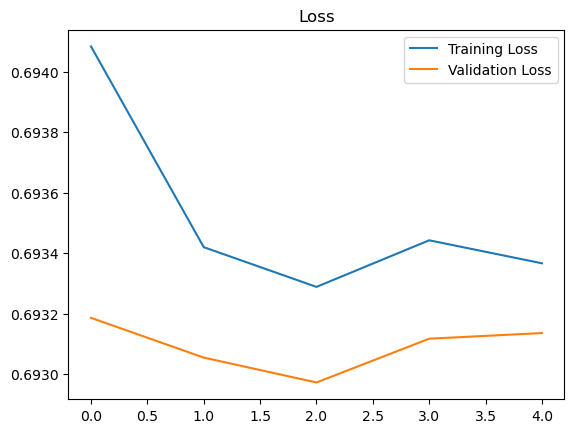

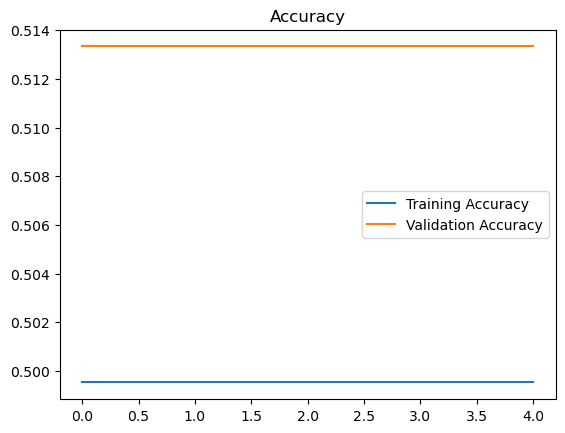

In [22]:
plot_metrics(history) 

In [23]:
import keras.backend as K

# Clear Keras session
K.clear_session()